[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/09_building_ai_pocs/35_rag_pipeline_deep_dive.ipynb)

# 📓 Notebook 35 — RAG Pipeline Deep Dive

> **Module:** Building AI POCs · **Estimated time:** ~3 h · **Difficulty:** Intermediate / Advanced

**Retrieval-Augmented Generation (RAG)** is the architectural pattern that fixes the two biggest weaknesses of standalone LLMs: hallucinations and knowledge cutoff (NB 27 §9–§10). Instead of asking the LLM to *recall* facts, you give it the relevant facts directly in the prompt — turning the task from *recall* into *reading comprehension*, which LLMs handle far better.

This is the *applied* deep-dive companion to NB 29 (Embeddings & Retrieval). Where NB 29 introduces vectors and similarity, this notebook walks the full production pipeline, names every trade-off knob, and ends with a runnable Streamlit POC that lets you chat with a PDF.

> 🎬 **Running example — ChurnScope's next rung.** Back in NB 34, ChurnScope learned to *score* which customers are at risk. But once the retention team sees a flagged account, their next question is *"what do we actually do about it?"* — and the answer lives in a 40-page **retention playbook PDF** nobody reads end to end. A generic LLM has never seen that playbook. So this notebook gives ChurnScope an open book: upload the playbook, ask *"what's our standard offer for a high-value monthly account threatening to cancel?"*, and get an answer grounded in the real document, with citations. RAG is how ChurnScope stops guessing and starts quoting.

> 🧭 **Mental model — the open-book exam.** This is the one picture to keep for the whole notebook: a standalone LLM is a student sitting a *closed-book* exam (answering from memory, sometimes confidently wrong); RAG turns it into an *open-book* exam (look up the right page first, then answer from it). The "smart" part you're adding isn't a smarter brain — it's a **librarian** who finds the right page before the model writes a word. Every section below is really about making that librarian land the right page.

---

## 🎯 Learning objectives

1. **Explain RAG** to a non-technical stakeholder using the *open-book exam* analogy.
2. **Draw the full RAG pipeline** end-to-end (offline indexing + online query).
3. **Choose chunking parameters** based on document type and use case.
4. **Pick an embedding model** matched to language, domain, and hosting constraints.
5. **Reason about ANN algorithms** (HNSW, IVF, IVF-PQ) and when each is right.
6. **Compute cosine similarity by hand** for a 3-D worked example.
7. **Tune the 5 production knobs** (chunk size, top-k, embedding dim, re-ranker, hybrid search).
8. **Build a RAG-over-PDF POC** in 30 minutes using one Copilot Agent prompt.

**Prerequisites:** NB 27 (LLM fundamentals), NB 29 (embeddings & retrieval — at least skim).

**Time budget:** ~100 minutes including the POC.


## 1. The core idea — connect the LLM to your knowledge

Here's the problem in one sentence: ChurnScope's retention playbook was written last quarter and is full of internal terms — a frontier LLM has never read a word of it. Ask it *"what's our save-offer for tier-2 accounts?"* and it will invent a plausible-sounding policy. We need it to answer from *our* document, not its memory.

**RAG** is an architecture that connects an LLM with an external knowledge base. Instead of relying solely on its internal weights, the model can *retrieve relevant information first*, then generate the answer with that information in its context.

### Analogy — the open-book exam

| Standalone LLM = **closed-book exam** | RAG system = **open-book exam** |
|---|---|
| The student may only answer from memory. | The student may consult the textbook. |
| Sometimes inaccurate or outdated. | More precise, current, and verifiable. |
| Hallucinations: confidently wrong. | Wrong answers are now traceable to *which page* failed. |

**Why this is so effective:** LLMs are not bad at recall *because they're bad at language*. They're bad at recall because *the universe of facts is too large to fit losslessly in any weight matrix*. Giving them the relevant facts directly sidesteps the entire problem. The model never needed to *memorise* the playbook — it just needs the right page open in front of it.


## 2. The RAG architecture at a glance

```
                                ┌──────────────────────────────────┐
                                │     Knowledge base               │
                                │   (docs, FAQs, product specs)    │
                                └────────────┬─────────────────────┘
                                             │
                                  retrieves  │
                                             ▼
  ┌─────────┐         ┌────────────┐    ┌────────────────┐         ┌──────────┐
  │  User   │ ──────► │  Retriever │ ──►│  Augmented     │  ──────►│   LLM    │ ─►  grounded
  │  query  │         │            │    │  prompt        │         │          │     answer
  └─────────┘         └────────────┘    └────────────────┘         └──────────┘
```

**The four-step process:**

1. User asks a question.
2. Retriever finds the most relevant chunks from the knowledge base.
3. Those chunks are stitched into an *augmented prompt* with explicit grounding instructions.
4. The LLM generates the answer using the provided evidence.

**Why this decoupling matters.** The model stays general-purpose; the knowledge can be updated, audited, and swapped *without re-training the model*. Add a new policy PDF on Monday → it's queryable on Tuesday.


## 3. The full pipeline — indexing vs query

RAG has *two* pipelines that run at different times:

**Phase 1 — Indexing (offline, batch).** Done once per document update. Slow.

```
  Documents ─► Chunk ─► Embed ─► Vector store (FAISS / Chroma / pgvector)
   (PDF, HTML, DB)                with metadata (source, page, timestamp)
```

**Phase 2 — Query (online, real-time).** Runs on every user question. Must be fast.

```
  User query ─► Embed (same model!) ─► Search top-k ─► Build augmented prompt ─► LLM ─► Answer
```

> ⚠️ **Key invariant.** The *query* embedding model and the *indexing* embedding model must be **identical**. Otherwise the geometric distances are meaningless. This is the #1 RAG bug in production: someone upgrades the embedding model but doesn't re-index.


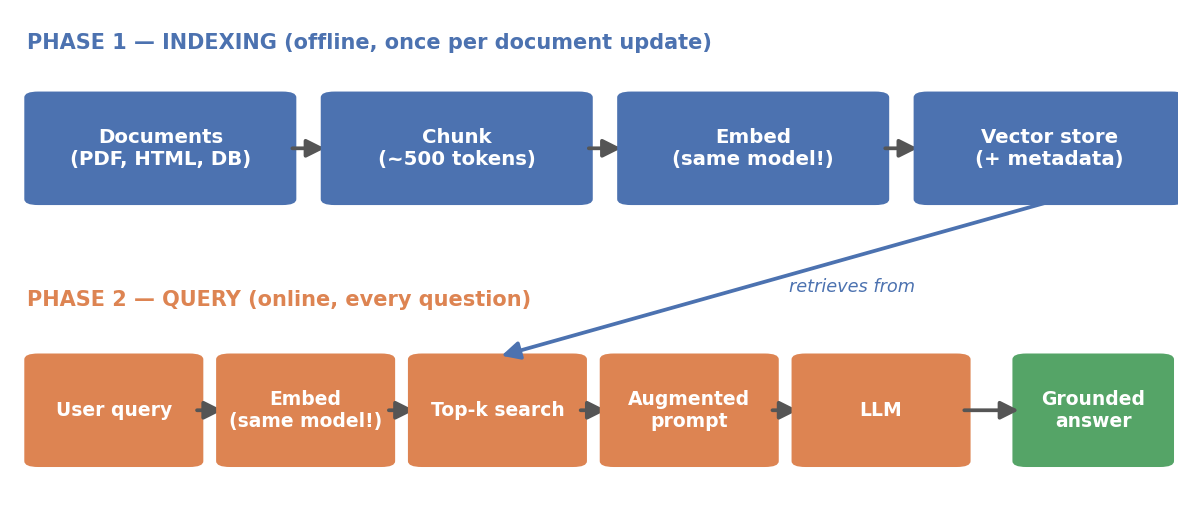


### 🔬 What actually happens between your question and the answer?

Sections 1–3 named the stages. This sub-section traces a *single question* through the whole machine, end to end, so the most important sentence in this notebook finally clicks:

> **The model does not *know* your documents. It *reads* the snippets you pasted into the prompt.**

RAG is **open-book, not memorized**. The LLM's weights are frozen and generic; your private/fresh facts live *outside* it, in a vector store. RAG's job is to find the right page of the open book and slide it under the model's nose at question time.

There are **two phases that run at different times** — keep them separate in your head:

```text
╔══════════════════════════ PHASE 1: INDEXING (offline, once) ══════════════════════════╗
║                                                                                        ║
║   your docs ──► SPLIT into chunks ──► EMBED each chunk ──► STORE vectors + text        ║
║   ┌────────┐      ┌──────────┐          ┌───────────┐        ┌──────────────────────┐  ║
║   │"Refunds│      │ chunk 0  │          │ [.9,.1,0] │        │  vector store        │  ║
║   │ within │  ──► │ chunk 1  │   ──►    │ [.1,.9,0] │  ──►   │  0: vec + "Refunds…" │  ║
║   │ 30 days│      │ chunk 2  │          │ [0,.1,.9] │        │  1: vec + "Shipping…"│  ║
║   │ …"     │      └──────────┘          └───────────┘        │  2: vec + "Returns…" │  ║
║   └────────┘                                                 └──────────────────────┘  ║
╚════════════════════════════════════════════════════════════════════════════════════════╝
                                                                          │ stored, waiting
                                                                          ▼
╔══════════════════════════ PHASE 2: QUERY (online, every question) ═════════════════════╗
║                                                                                        ║
║  question ─► EMBED ─► top-k by COSINE ─► STUFF chunks into prompt ─► llm(prompt) ─► ans ║
║  ┌────────┐  ┌──────┐   ┌──────────┐      ┌────────────────────┐    ┌──────┐    ┌─────┐ ║
║  │"how    │  │ q =  │   │ score    │      │ "Context:          │    │ LLM  │    │ "30 │ ║
║  │ long to│─►│[.85, │──►│ chunk0 ✔ │ ───► │  [1] Refunds 30d…  │──► │reads │──► │days"│ ║
║  │ refund?"│ │ .12, │   │ chunk2   │      │  Question: how…?"  │    │ ctx  │    │     │ ║
║  └────────┘  │  0 ] │   │ chunk1   │      └────────────────────┘    └──────┘    └─────┘ ║
║              └──────┘   └──────────┘            ▲ the answer is HERE, in the prompt     ║
╚════════════════════════════════════════════════════════════════════════════════════════╝
```

The arrow that matters most is **"STUFF chunks into prompt"**. The retrieved text is *literally concatenated* into the string you send the model. The model then answers by *reading* that string — exactly like a student copying the relevant paragraph onto their answer sheet before writing the response.

### "Memorized" vs "retrieved" — two very different ways a model can answer

When an LLM gives you a fact, it came from one of two places. RAG forces it into the **right** column:

| | Memorized (no RAG) | Retrieved (RAG) |
|---|---|---|
| Where the fact lives | Baked into the frozen weights during training | In your vector store, *outside* the model |
| How the model "gets" it | Recalls it from billions of parameters | **Reads** it from text pasted into the prompt |
| Fresh / private facts? | ❌ Cutoff date; never saw your internal docs | ✅ Add a doc today, answerable today |
| Can you cite the source? | ❌ No idea which training page it came from | ✅ The exact chunk + its metadata |
| Failure mode | Confident hallucination | If retrieval **misses**, the model has nothing to read → says "I don't know" *or* (worse) falls back to memorized guessing |
| Exam analogy | Closed-book, from memory | Open-book, copy from the page |

> 🧠 **The one-line mental model:** **RAG = retrieve relevant chunks, then let the model answer *from them*.** The intelligence you're adding isn't smarter weights — it's a *librarian* that finds the right page before the model writes a word.

This is also exactly **why RAG beats fine-tuning for fresh/private facts** (full table in §13): fine-tuning *re-bakes* knowledge into the weights — slow, expensive, and stale the moment a policy changes. RAG just drops a new file into the store. Updating knowledge becomes a *file copy*, not a *training run*.

### 🧪 Proof — a complete mini-RAG in ~40 lines, fully offline

Time to *see* it. The cell below is a real RAG pipeline with every API ripped out and replaced by something you can read:

- **Documents:** three tiny inline strings.
- **Embeddings:** hand-assigned toy `numpy` vectors (in real life MiniLM/OpenAI produce these — here we pick them by hand so the geometry is obvious). Each vector leans toward one "topic axis": `[refunds, shipping, returns]`.
- **Retrieval:** real cosine similarity, real top-k.
- **`llm(prompt)`:** a **mock** model — it does *no* reasoning; it just proves the retrieved context is sitting in the prompt by reading the answer straight out of it.

No network, no keys, no GPU. Run it and watch the chunk travel from the store into the prompt and out as the answer.

In [1]:
import numpy as np

# ── PHASE 1: INDEXING (offline) — done ONCE, ahead of any question ──────────────
# Our "documents". In production these are chunks of your PDFs / wiki / DB rows.
DOCS = [
    "Refunds are issued within 30 days of the original purchase date.",
    "Standard shipping takes 5 to 7 business days to arrive.",
    "Returned items must be unworn and in their original packaging.",
]

# Toy embeddings, ONE per chunk. Axes = [refunds, shipping, returns].
# A real embedding model outputs these 384/768/1536-dim vectors for you;
# we hand-pick 3-D ones so you can SEE which topic each chunk leans toward.
DOC_VECS = np.array([
    [0.97, 0.10, 0.22],   # doc 0 — strongly "refunds"
    [0.12, 0.96, 0.08],   # doc 1 — strongly "shipping"
    [0.20, 0.05, 0.98],   # doc 2 — strongly "returns"
])

# The "vector store" is just these vectors paired with their source text.
STORE = list(zip(DOC_VECS, DOCS))
print("Indexed", len(STORE), "chunks. The store now holds vector + text pairs:")
for i, (vec, text) in enumerate(STORE):
    print(f"  [{i}] {vec}  ->  {text!r}")


Indexed 3 chunks. The store now holds vector + text pairs:
  [0] [0.97 0.1  0.22]  ->  'Refunds are issued within 30 days of the original purchase date.'
  [1] [0.12 0.96 0.08]  ->  'Standard shipping takes 5 to 7 business days to arrive.'
  [2] [0.2  0.05 0.98]  ->  'Returned items must be unworn and in their original packaging.'


In [2]:
# ── PHASE 2a: RETRIEVE — embed the question, score every chunk by COSINE ───────
def cosine(a, b):
    """Angle-based similarity in [-1, 1]; higher = more similar (see §8)."""
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

def embed_query(text):
    """MOCK query embedder. A real model maps text -> the SAME space as DOC_VECS.
    Here we hard-code one query's vector so the demo is deterministic & offline."""
    # "how long do refunds take?" leans hard on the 'refunds' axis:
    return np.array([0.90, 0.18, 0.15])

def retrieve(query, k=2):
    q = embed_query(query)
    scored = [(cosine(q, vec), i, text) for i, (vec, text) in enumerate(STORE)]
    scored.sort(reverse=True)                 # highest cosine first
    return scored[:k]                         # top-k chunks

question = "How long do refunds take?"
hits = retrieve(question, k=2)

print(f"Question: {question!r}\n")
print("Cosine score for every chunk (this is the 'search'):")
for score, i, text in sorted([(cosine(embed_query(question), v), i, t)
                              for i, (v, t) in enumerate(STORE)], reverse=True):
    mark = "  <- RETRIEVED" if (score, i, text) in hits else ""
    print(f"  doc {i}: {score:.3f}  {text!r}{mark}")


Question: 'How long do refunds take?'

Cosine score for every chunk (this is the 'search'):
  doc 0: 0.994  'Refunds are issued within 30 days of the original purchase date.'  <- RETRIEVED
  doc 2: 0.361  'Returned items must be unworn and in their original packaging.'  <- RETRIEVED
  doc 1: 0.324  'Standard shipping takes 5 to 7 business days to arrive.'


In [3]:
# ── PHASE 2b: AUGMENT — STUFF the retrieved chunks into the prompt ─────────────
def build_prompt(question, hits):
    context = "\n".join(f"[{n+1}] {text}" for n, (score, i, text) in enumerate(hits))
    return (
        "Answer the question using ONLY the context below. "
        "If it is not in the context, say \"I don't know\".\n\n"
        f"<context>\n{context}\n</context>\n\n"
        f"Question: {question}"
    )

# ── PHASE 2c: GENERATE — a MOCK llm that PROVES it answers from the prompt ──────
def llm(prompt):
    """Not a real model — no reasoning. It just demonstrates that the answer
    is physically present in the prompt text by reading a fact back out of it."""
    if "30 days" in prompt:
        return "Refunds are issued within 30 days of the original purchase date. [1]"
    return "I don't know"   # nothing relevant was retrieved -> can't answer

prompt = build_prompt(question, hits)
print("=" * 70)
print("THE EXACT PROMPT SENT TO THE MODEL (retrieved text is now INSIDE it):")
print("=" * 70)
print(prompt)
print("=" * 70)
print("MODEL ANSWER:", llm(prompt))
print()
print("Notice: the model 'knew' nothing. The fact '30 days' rode IN on the")
print("retrieved chunk. Delete that chunk from the prompt and the answer vanishes.")


THE EXACT PROMPT SENT TO THE MODEL (retrieved text is now INSIDE it):
Answer the question using ONLY the context below. If it is not in the context, say "I don't know".

<context>
[1] Refunds are issued within 30 days of the original purchase date.
[2] Returned items must be unworn and in their original packaging.
</context>

Question: How long do refunds take?
MODEL ANSWER: Refunds are issued within 30 days of the original purchase date. [1]

Notice: the model 'knew' nothing. The fact '30 days' rode IN on the
retrieved chunk. Delete that chunk from the prompt and the answer vanishes.


In [4]:
# ── FAILURE MODE: when RETRIEVAL MISSES, the model has nothing to read ─────────
# Ask something NONE of our 3 chunks cover. Retrieval still returns its "best"
# matches, but they are irrelevant -> the fact simply isn't in the prompt.
def embed_off_topic(text):
    return np.array([0.10, 0.12, 0.15])      # leans toward no strong axis

q2 = "Do you offer gift wrapping?"
scored = [(cosine(embed_off_topic(q2), vec), i, text)
          for i, (vec, text) in enumerate(STORE)]
scored.sort(reverse=True)
hits2 = scored[:2]

prompt2 = build_prompt(q2, hits2)
print("Question:", q2)
print("Top chunks retrieved (best-effort, but OFF-TOPIC):")
for score, i, text in hits2:
    print(f"  doc {i}: {score:.3f}  {text!r}")
print("\nMODEL ANSWER:", llm(prompt2))   # -> "I don't know": no '30 days', nothing relevant
print()
print("This is the #1 RAG failure: the generator is only as good as the")
print("retriever. Miss the chunk -> the model must say 'I don't know' (good)")
print("or, with weak grounding, hallucinate from memory (bad). Fix RETRIEVAL,")
print("not the prompt: bigger chunks, higher k, a better embedding model (§11, Ex 4).")


Question: Do you offer gift wrapping?
Top chunks retrieved (best-effort, but OFF-TOPIC):
  doc 2: 0.798  'Returned items must be unworn and in their original packaging.'
  doc 1: 0.662  'Standard shipping takes 5 to 7 business days to arrive.'

MODEL ANSWER: I don't know

This is the #1 RAG failure: the generator is only as good as the
retriever. Miss the chunk -> the model must say 'I don't know' (good)
or, with weak grounding, hallucinate from memory (bad). Fix RETRIEVAL,
not the prompt: bigger chunks, higher k, a better embedding model (§11, Ex 4).


### 🎯 Lock in the mental model

You just ran a RAG end to end with zero API calls. Three things to carry forward:

1. **The model is open-book, not omniscient.** Its answer was lifted from the chunk you stuffed into the prompt — the toy `llm()` did no reasoning at all, yet still "answered", because *the fact was in the prompt*. Real models add fluent reading comprehension on top of this exact mechanism.
2. **Retrieval is the whole ballgame.** Same model, same prompt template — but in the off-topic run the answer collapsed to "I don't know" purely because the right chunk never made it into the context. When RAG fails, print the retrieved chunks first (Ex 4 & 5).
3. **Fresh/private knowledge is a file, not a re-train.** To teach this system about gift wrapping, you don't fine-tune anything — you add one string to `DOCS` and re-embed it. That `O(1)` update is the core reason RAG beats fine-tuning for changing facts.

> 🧠 **Carry this sentence:** **RAG = retrieve relevant chunks, then let the model answer from them — it's open-book, not memorized.** Everything else in this notebook (chunking, embedding choice, cosine, top-k, the five knobs) is just *making the retrieve step land the right chunk in the prompt.*

---

### ✋ Quick exercise (~2 min) — Retrieve a different chunk

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The mini-RAG above answered a *refunds* question. A teammate now asks a **shipping** question. Using only `cosine()` and `STORE` from the cells above, score every chunk against the toy query below and print the single best-matching chunk.

```python
q = np.array([0.15, 0.92, 0.10])   # a "shipping"-flavoured question
```

In [5]:
# ✍️ Your turn 👇
# cosine() and STORE are still defined from the mini-RAG above.
q = np.array([0.15, 0.92, 0.10])   # a "shipping"-flavoured question
# Score every chunk in STORE with cosine() and print the single best match.


<details>
<summary>✅ <b>Solution</b></summary>

```python
scores = [(cosine(q, vec), text) for vec, text in STORE]
best = max(scores)
print(f"{best[0]:.3f}  ->  {best[1]!r}")
```

A "shipping" query leans on the shipping axis, so `cosine()` scores doc 1 highest — the librarian lands the right chunk by angle, not keyword.
</details>

## 4. Step 1–2 — Ingestion and chunking

### Ingestion

Parse the raw documents into clean text:

- **PDF** → `pypdf`, `pdfplumber`, `unstructured`.
- **HTML** → `BeautifulSoup` + boilerplate stripping.
- **Word / PowerPoint** → `python-docx`, `python-pptx`.
- **Confluence / Notion / DB** → use the source's API.

**Always preserve metadata:** source filename, page number, section, author, date. This is what makes citations possible later.


### Chunking strategies

**Why chunk?** LLM context windows are limited and *retrieval is more precise on small units*. A 200-page PDF is hopeless to retrieve as one blob — chunked into ~500-token slices, you can pinpoint the exact paragraph.

| Strategy | How | Best for |
|---|---|---|
| **Fixed-size** | 500 tokens with 50 overlap | Default starting point. Simple, predictable. |
| **Recursive char split** | First by paragraph, then by sentence, then by character | Mixed-structure documents (technical docs with headings). |
| **Semantic chunking** | Split where embedding distance jumps | When meaning-boundaries don't align with paragraphs (transcripts). |
| **Document-structure aware** | Use the doc's own headings / sections | Well-structured docs (legal, regulatory). |

**Why chunk size matters — the trade-off in one line:**

*Too small → loses context, the retrieved chunk doesn't have enough information. Too large → noisy retrieval, the chunk has the answer plus a lot of irrelevant text that confuses the LLM.*

> 💡 **Sweet spot:** 200–800 tokens with 10–20% overlap. Start at 500/50 and tune from there.


## 5. Step 3 — Embeddings

An **embedding** is a learned function $f : \text{text} \to \mathbb{R}^d$ that maps text to a *dense vector* — a list of $d$ numbers (typically $d = 384, 768$, or $1536$) where *texts with similar meaning land close together*.

### Reading the notation, symbol by symbol

| Symbol | What it means |
|---|---|
| $f$ | A function — takes input, returns output. |
| `text` | The input: a chunk of text. |
| $\rightarrow$ | "maps to" / "returns". |
| $\mathbb{R}$ | The real numbers — any decimal. |
| $\mathbb{R}^d$ | A list (vector) of $d$ real numbers. |

**Concrete example with $d=4$:**

$$f(\text{"apple"}) = [0.71, -0.04, 0.32, 0.62]$$
$$f(\text{"banana"}) = [0.66, 0.02, 0.41, 0.58]$$

These vectors point in nearly the same direction → "apple" and "banana" are semantically close in the model's representation. **Retrieval becomes geometry.**


### Choosing an embedding model in 2026

| Model | Dim / Provider | Notes |
|---|---|---|
| `all-MiniLM-L6-v2` | 384, sentence-transformers (local) | Fast, tiny, good baseline. **Default for the POC below.** |
| `bge-large-en-v1.5` | 1024, BAAI (local) | Strong open-source. Multilingual variants exist. |
| `text-embedding-3-small` | 1536, OpenAI (API) | High quality, low cost, easy to swap. |
| `voyage-3` | 1024, Voyage AI (API) | Specifically tuned for retrieval. |

**Four axes to decide on:**

- **Domain.** General-purpose vs domain-tuned (legal, biomedical, finance).
- **Language.** English-only vs multilingual.
- **Size.** Smaller = faster and cheaper, but loses recall on subtle queries.
- **Hosting.** Local (no API cost, full privacy) vs API (no GPU needed).

> 🧠 **Rule.** *Always benchmark on YOUR retrieval set.* Embedding-model leaderboards are useful priors, but the model that wins on academic benchmarks isn't always the best on your specific corpus.


In [6]:
# Minimal embedding example — no API call needed.
# Run this locally with: pip install sentence-transformers
# (skipped here — this cell is a reference, not for execution)

EXAMPLE_CODE = """
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
chunks = ['apples are red', 'bananas are yellow', 'cars have wheels']
vectors = model.encode(chunks)
print(vectors.shape)  # (3, 384)
"""
print(EXAMPLE_CODE)



from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
chunks = ['apples are red', 'bananas are yellow', 'cars have wheels']
vectors = model.encode(chunks)
print(vectors.shape)  # (3, 384)



---

### ✋ Quick exercise (~2 min) — Are these embeddings close?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Section 5 claims that "texts with similar meaning land close together" in embedding space. Put a number on it: reuse the `cosine()` helper from the mini-RAG to measure the similarity of the two toy embedding vectors below. Is the result near 1 (close) or near 0 (unrelated)?

```python
apple  = np.array([0.71, -0.04, 0.32, 0.62])
banana = np.array([0.66,  0.02, 0.41, 0.58])
```

In [7]:
# ✍️ Your turn 👇
# cosine() is still defined from the mini-RAG above.
apple  = np.array([0.71, -0.04, 0.32, 0.62])
banana = np.array([0.66,  0.02, 0.41, 0.58])
# Use cosine() to measure how close these two embedding vectors are.


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(round(cosine(apple, banana), 3))   # ~0.992
```

A cosine near 1.0 means the two vectors point almost the same direction — exactly what we expect for two semantically related fruits. "Similar meaning → close in vector space" is the whole premise of embedding-based retrieval.
</details>

## 6. Step 4 — Vector storage

**Why a vector store?** You need to search millions of vectors in milliseconds. A vector database provides:

- Efficient **Approximate Nearest Neighbour (ANN)** indexing (HNSW, IVF, IVF-PQ).
- Persistent storage of vectors *plus metadata* (source, chunk_id, timestamp, author).
- Metadata filtering — *"only docs from 2025"*, *"only by author X"*.

**Five options, mapped to use-cases** (full landscape covered in NB 36):

- **FAISS** — local library, very fast, no server. *Prototypes.*
- **Chroma** — developer-friendly Python API, local or self-hosted. *POCs, RAG demos.* **Used in the POC below.**
- **Qdrant** — Rust-based open-source server, strong filtering. *Self-hosted production.*
- **Pinecone** — managed cloud, low-latency SLAs. *Managed production at scale.*
- **pgvector** — Postgres extension. *Reuse existing Postgres infra.*


## 7. 🧠 Approximate Nearest Neighbour (ANN) — under the hood

**The problem.** You have $N$ stored vectors and want the $k$ closest to a query vector. The naive method (compare to every vector) is $\mathcal{O}(N)$ — infeasible at $N = 10^9$.

**The trick.** ANN algorithms pre-build an *index* so only a small fraction of the database is inspected. We accept a small recall loss (e.g., 95% instead of 100% of true neighbours found) for a **10–100× speed-up**.

| Index | Idea | When to use |
|---|---|---|
| **HNSW** | Multi-layer *small-world graph*; greedy walk to nearest neighbour. | Default for modern stores (Chroma, Qdrant, pgvector, Weaviate). Fast and accurate. |
| **IVF** | k-means cluster the vectors; search only the few nearest clusters. | Massive datasets where memory is a constraint. |
| **IVF-PQ** | IVF + Product Quantization: compress each vector to a few bytes. | Billion-scale on commodity hardware. |

**Why you usually don't tune ANN yourself.** Modern vector databases pick sensible defaults (often HNSW). The day you do need to tune is when your collection grows past ~10 M vectors and either query latency or memory becomes the bottleneck.


## 8. Step 5 — Similarity search

Most retrieval uses **cosine similarity**, which measures the angle between two vectors:

$$\cos(\mathbf{q}, \mathbf{d}) = \frac{\mathbf{q} \cdot \mathbf{d}}{\|\mathbf{q}\| \, \|\mathbf{d}\|}$$

- **Numerator:** the *dot product* $\mathbf{q} \cdot \mathbf{d} = \sum_i q_i d_i$.
- **Denominator:** the *vector lengths* $\|\mathbf{q}\| = \sqrt{\sum_i q_i^2}$ and similarly for $\mathbf{d}$.
- **Range:** $[-1, 1]$. Higher = more similar.
- **Geometric meaning:** the *cosine of the angle* between the two arrows.

**Three other metrics you may encounter:**

- **Dot product** — cheap; equivalent to cosine when vectors are L2-normalised. The default for normalised text embeddings.
- **Euclidean (L2) distance** — cares about magnitude; less common for modern embeddings.
- **Inner product (IP)** — what FAISS's `IndexFlatIP` uses; same as dot product.


### 🧠 Worked example — cosine similarity by hand

Three toy 3-D vectors against a query:

$$\mathbf{q} = [1, 0, 1], \quad \mathbf{d}_1 = [1, 1, 0], \quad \mathbf{d}_2 = [0, 1, 1], \quad \mathbf{d}_3 = [1, 0, 1]$$

Compute the pieces:

| | $\mathbf{q} \cdot \mathbf{d}$ | $\|\mathbf{q}\|$ | $\|\mathbf{d}\|$ | $\cos(\mathbf{q}, \mathbf{d})$ |
|---|---:|---:|---:|---:|
| $\mathbf{d}_1$ | $1{\cdot}1 + 0{\cdot}1 + 1{\cdot}0 = 1$ | $\sqrt{2}$ | $\sqrt{2}$ | $1/2 = 0.50$ |
| $\mathbf{d}_2$ | $1{\cdot}0 + 0{\cdot}1 + 1{\cdot}1 = 1$ | $\sqrt{2}$ | $\sqrt{2}$ | $1/2 = 0.50$ |
| $\mathbf{d}_3$ | $1{\cdot}1 + 0{\cdot}0 + 1{\cdot}1 = 2$ | $\sqrt{2}$ | $\sqrt{2}$ | $2/2 = 1.00$ |

**Geometric reading.**

- $\cos = 1$: same direction → perfect match (here, $\mathbf{d}_3$ which equals $\mathbf{q}$).
- $\cos = 0$: orthogonal → unrelated.
- $\cos = -1$: opposite direction.

**Magnitude is ignored** — only the *angle* between the two arrows matters. That's why *doubling all numbers in a vector does not change retrieval*.


---

### ✋ Quick exercise (~2 min) — Cosine for a new query

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The worked example used $\mathbf{q} = [1, 0, 1]$. Now the query changes to $\mathbf{q} = [1, 1, 0]$. Using the `cosine()` helper, rank the same three documents and identify the top match — predict the winner before you run it.

```python
q  = np.array([1, 1, 0])
d1 = np.array([1, 1, 0]); d2 = np.array([0, 1, 1]); d3 = np.array([1, 0, 1])
```

In [8]:
# ✍️ Your turn 👇
# cosine() is still defined from the mini-RAG above.
q  = np.array([1, 1, 0])
d1 = np.array([1, 1, 0]); d2 = np.array([0, 1, 1]); d3 = np.array([1, 0, 1])
# Rank d1, d2, d3 by cosine(q, .) and say which is the top match.


<details>
<summary>✅ <b>Solution</b></summary>

```python
for name, d in [("d1", d1), ("d2", d2), ("d3", d3)]:
    print(name, round(cosine(q, d), 3))
# d1 = 1.0  (identical direction)  >  d2 = 0.5  =  d3 = 0.5
```

`d1` equals `q`, so the angle is zero → cosine = 1.0 (a perfect match). `d2` and `d3` each share just one axis with `q`, giving 0.5. Highest cosine = top retrieval result.
</details>

## 9. Step 6–7 — Prompt augmentation + generation

The retrieved chunks are stitched into a *system / context block* with **explicit grounding instructions**:

```
You are a support assistant. Answer the question using ONLY the context below.
If the answer is not in the context, say "I don't know".

<context>
[1] {chunk_1}  (source: policy.pdf, p. 4)
[2] {chunk_2}  (source: order_db, id 8821)
...
</context>

Question: {user_question}

Cite sources as [1], [2].
```

**Two design knobs that change everything:**

- **Grounding instruction** (*"answer ONLY from the context"*) — reduces hallucinations.
- **Citation requirement** — forces the model to point at evidence, making outputs *auditable*.

**Practical patterns:**

- Numbered context blocks `[1]`, `[2]`, ... — citations become straightforward.
- Explicit *"I don't know"* clause — avoids fabricated answers when retrieval fails.
- Source metadata (file, page, date) — lets users verify each claim.
- **Token budget:** cap context length and drop low-similarity chunks first.


## 10. Why RAG reduces hallucinations

**Without RAG.** The LLM must *recall* facts from frozen training weights. When the topic is unfamiliar or out-of-distribution, the model still produces fluent text → plausible but wrong.

**With RAG.** The LLM is given the relevant evidence directly in the prompt. The task shifts from *recall* to *reading comprehension*, which LLMs handle far better.

**What RAG does NOT fix:**

- *Bad retrieval* → irrelevant context → wrong answer (garbage in, garbage out).
- *LLM ignoring the context* (mitigated by stronger prompting and instruction-tuned models).
- *Conflicting sources* (handled with re-ranking, source weighting, conflict-resolution prompts).

> 🎯 **Mental shift:** *RAG turns a recall problem into a reading-comprehension problem*. Fluency the LLM already has; understanding evidence is much easier than remembering it.


## 11. ⚙️ The five production tuning knobs

Once your RAG is running, these are the levers that change quality, cost, and latency:

| Knob | Increase | Decrease |
|---|---|---|
| Chunk size | More context per chunk; fewer chunks | More precise retrieval; less noise |
| Top-$k$ retrieved | Higher recall, less likely to miss | Lower latency, smaller prompt cost |
| Embedding dimension | Richer semantics | Faster, cheaper storage |
| Re-ranker (cross-encoder) | Higher precision after retrieval | Removes extra latency stage |
| Hybrid search (BM25 + vector) | Robust to keyword queries | Pure vector is simpler to operate |

**Operational considerations:**

- **Latency budget:** embedding + ANN search + LLM call ≈ 0.5–3 s typical.
- **Cost:** dominated by LLM tokens. Context size matters more than embedding count.
- **Freshness:** re-index incrementally; use timestamps and TTLs to expire old chunks.

> 💡 **Where to start tuning.** In order: (1) chunk size + overlap, (2) top-$k$, (3) prompt template, (4) embedding model. Re-ranker and hybrid search come later, when the first four are exhausted.


---

### ✋ Quick exercise (~2 min) — Turn the top-k knob

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You just met the five tuning knobs. Turn one of them on the live mini-RAG: call `retrieve()` for the refunds question with `k=1` and again with `k=3`, and print how many chunks each returns. Which of the five knobs did you adjust, and what does raising it cost?

```python
question = "How long do refunds take?"
```

In [9]:
# ✍️ Your turn 👇
# retrieve() is still defined from the mini-RAG above.
question = "How long do refunds take?"
# Call retrieve() with k=1 and k=3 and print how many chunks come back each time.
# Which of the five production knobs did you just turn?


<details>
<summary>✅ <b>Solution</b></summary>

```python
question = "How long do refunds take?"
for k in (1, 3):
    hits = retrieve(question, k=k)
    print(f"k={k}: {len(hits)} chunk(s) retrieved")
```

You turned the **top-k** knob (knob #2). A larger `k` raises recall (less likely to miss the right chunk) but enlarges the prompt — more tokens, higher cost and latency. That recall-vs-cost trade-off is exactly what the five-knob table describes.
</details>

## 12. Realistic example — the customer-service bot

Pipeline assembled, knobs named — now watch one full query travel through it, librarian and all. (The scenario here is a support bot; it's the *exact same machine* as ChurnScope's playbook assistant, just pointed at order data and return policies instead of the retention playbook.)

**Scenario.** An e-commerce company wants an AI chatbot answering customer questions about products, orders, returns.

**End-to-end trace of one query:**

| Step | What happens |
|---|---|
| User query | *"Can I still cancel the Blue-Sky Sneaker I ordered yesterday?"* |
| Retrieval | Finds: (1) return policy chunk, (2) order status: *"Shipment being prepared"*. |
| Augmented prompt | Query + Context: *"Cancellations possible until shipment. Status: shipment being prepared."* |
| LLM response | *"Yes, you can still cancel your order as it has not yet been shipped."* |

**Why this works in production:**

- **Order data** comes from the live ERP / order DB — always current.
- **Policy text** is re-indexed whenever Legal updates the document — no model re-training.
- **Citations** let support agents verify the bot's reasoning before escalation.
- **Fallback:** if retrieval confidence is low, hand off to a human agent.

**Without RAG**, the model would have known neither the current order status nor the company's specific return policies and could only have made general statements. Swap "order status + return policy" for "churn score + retention playbook" and you have ChurnScope's assistant — same librarian, different shelf.


## 13. RAG vs fine-tuning — decide once

| Question | Pick RAG | Pick fine-tuning |
|---|---|---|
| The knowledge changes monthly. | ✓ | |
| You need *citations* to source documents. | ✓ | |
| The model needs to *speak in our tone*. | | ✓ |
| The model needs to follow our specific *format* every time. | | ✓ |
| Compliance requires we can audit every claim. | ✓ | |
| The use case is domain jargon-heavy and base model misuses terms. | both | both |

**General principle (from NB 27):**

- **RAG** for *knowledge* — what the model knows.
- **Fine-tuning** for *behaviour* — how the model speaks.
- **Combine both** when the use case needs custom knowledge *and* custom tone.


## 14. 🛠️ POC — Chat with your PDF

Theory's done — time to be the architect again (NB 33's loop still applies: describe → generate → review). This is the POC that gives ChurnScope its open book.

**Use case.** The retention team has a 40-page internal **playbook** PDF. Reading it end-to-end before every at-risk call is slow, and a generic LLM can't see it. We want a small Streamlit app where the team uploads the playbook and asks questions in natural language — *"what's the standard save-offer for a high-value monthly account?"* — answered *only* from the document, with citations they can trust.

**Goal.** A *single* Streamlit app (`app.py`) that ingests a PDF, builds a local FAISS index over chunks, retrieves top-$k$ chunks per question, and lets an LLM answer with grounded citations. No backend, no database. (Any PDF works for testing — point it at the playbook, a policy doc, or even a Wikipedia export.)


### POC — Architecture

```
  Indexing phase (once at upload time):
    PDF ─► pypdf ─► chunks (500 tok, 50 overlap) ─► MiniLM ─► FAISS index

  Query phase (every question):
    user query ─► MiniLM ─► top-k chunks ─► augmented prompt ─► LLM ─► answer + citations
```

**Why this is tiny:** indexing runs *in-process* at upload time; retrieval and generation run on every question. No backend service, no persistent DB. One Streamlit app, ~80 lines of code.


### POC — Steps in Agent Mode

1. Create folder `poc4_rag_pdf/` in your monorepo and a fresh venv.
2. Open in VS Code, switch Copilot Chat to **Agent** mode.
3. Send the prompt on the next cell — the agent creates `app.py`, `requirements.txt`, `.gitignore`, README.
4. Set your `ANTHROPIC_API_KEY` (or your provider equivalent) in the shell environment.
5. Run `streamlit run app.py`. Upload a PDF (your own, or download a Wikipedia-PDF for testing).
6. Ask 3-5 questions about the PDF; verify the answers cite real passages.
7. Iterate: vary chunk size and $k$, watch how the answers change.


### POC — Agent-Mode prompt

```
Build a single-file Streamlit app app.py that does Retrieval-Augmented
Generation over a user-uploaded PDF. Use pypdf to extract text, split it into
chunks of 500 tokens with 50-token overlap, embed each chunk with
sentence-transformers model all-MiniLM-L6-v2, and store the vectors in an
in-memory FAISS index (cosine via inner product on normalised embeddings).
On each user question, embed the query with the same model, retrieve the top-k
chunks (k configurable in a sidebar slider, default 4), build an augmented
prompt that instructs the LLM to answer ONLY from the provided context and
cite chunks as [1], [2], and call the Anthropic API (claude-sonnet-5, key
from ANTHROPIC_API_KEY). Add requirements.txt (streamlit, pypdf,
sentence-transformers, faiss-cpu, anthropic), a .gitignore (.venv/, .env,
*.pdf), and a short README with the run command.
```

**Why this prompt produces *your* app:**

- **Stack named explicitly:** Streamlit, pypdf, sentence-transformers, FAISS, Anthropic.
- **Concrete parameters:** chunk size 500, overlap 50, $k$ default 4, model `all-MiniLM-L6-v2` — reproducible.
- **Grounding rule in the prompt:** *"answer ONLY from context"* plus citation requirement → keeps the LLM honest.
- **Operational glue:** `requirements.txt`, `.gitignore`, README → project runs on a fresh machine.


### POC — Self-check

- [ ] The app starts; the upload widget accepts a PDF.
- [ ] After upload, the app prints something like *"Indexed 87 chunks from policy.pdf"*.
- [ ] Asking a question about content **in the PDF** returns a citation-laden answer (`[1]`, `[2]`).
- [ ] Asking a question about content **NOT in the PDF** returns *"I don't know"* or *"the document doesn't say"*.
- [ ] Reducing the sidebar slider to $k=1$ produces noticeably shorter / less-grounded answers; raising it to $k=8$ produces longer but sometimes noisier answers.

**If the model answers from its own knowledge instead of the PDF**, the grounding instruction is too weak. Re-prompt the agent: *"Strengthen the grounding rule — if the context does not mention X, refuse to answer about X."*


## 🧪 Practice exercises

### Exercise 1 — ⭐ Open-book exam analogy

A non-technical colleague asks: *"You keep saying RAG. What does that mean?"* Explain in 3-4 sentences using the open-book exam analogy, ending with a concrete example from your work.

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**Example explanation:**

> *"RAG stands for Retrieval-Augmented Generation. Think of a standard ChatGPT as a closed-book exam — it answers from memory and sometimes makes things up. RAG is the open-book version: when you ask a question, the system first looks up the relevant pages from your own documents, then asks the AI to answer using only those pages, with citations. In our team, we'd use RAG so the support chatbot can answer customer questions from our actual help-centre articles — and if it can't find the answer there, it says so instead of inventing one."*

**What's good about this:** explicit definition, the analogy is memorable, the citation point is non-obvious, and the concrete-from-our-work example makes it land.
</details>

### Exercise 2 — ⭐ Chunking trade-offs

For each scenario, suggest a chunk size + overlap and justify in one sentence:

a. A 200-page legal contract with clearly numbered clauses.
b. A collection of customer support transcripts (multi-turn conversations).
c. Technical API documentation with code examples interleaved with prose.
d. Twitter/X posts (each one max 280 characters).

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**a. ~400 tokens, 50 overlap, document-structure aware (split by clause).** Legal clauses are self-contained units; chunking respects the document's own boundaries.

**b. ~600 tokens, 100 overlap, recursive.** Conversation context matters — you need enough turns in one chunk to make sense; bigger overlap keeps multi-turn references intact.

**c. ~500 tokens, 50 overlap, but code blocks treated as atomic** — never split a code block. Mixed content is the trickiest; the rule is *never* break code or tables across chunks.

**d. ~280 chars per chunk, 0 overlap.** Each tweet is already an atomic unit; chunking smaller loses meaning, chunking larger combines unrelated posts.
</details>

### Exercise 3 — ⭐⭐ Compute cosine similarity

Given the query $\mathbf{q} = [2, 1]$, rank these three documents by cosine similarity (show your work):

$$\mathbf{d}_A = [4, 2], \quad \mathbf{d}_B = [-1, 3], \quad \mathbf{d}_C = [1, 0]$$

Which is most similar? Why doesn't *magnitude* affect the ranking?

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**Compute each:**

- $\mathbf{q} \cdot \mathbf{d}_A = 2{\cdot}4 + 1{\cdot}2 = 10$. $\|\mathbf{q}\| = \sqrt{5}$, $\|\mathbf{d}_A\| = \sqrt{20}$. $\cos = 10 / (\sqrt{5} \cdot \sqrt{20}) = 10/10 = \mathbf{1.00}$.
- $\mathbf{q} \cdot \mathbf{d}_B = 2{\cdot}(-1) + 1{\cdot}3 = 1$. $\|\mathbf{d}_B\| = \sqrt{10}$. $\cos = 1 / (\sqrt{5} \cdot \sqrt{10}) \approx 1/\sqrt{50} \approx \mathbf{0.14}$.
- $\mathbf{q} \cdot \mathbf{d}_C = 2{\cdot}1 + 1{\cdot}0 = 2$. $\|\mathbf{d}_C\| = 1$. $\cos = 2 / (\sqrt{5} \cdot 1) = 2/\sqrt{5} \approx \mathbf{0.89}$.

**Ranking:** $\mathbf{d}_A$ (1.00) > $\mathbf{d}_C$ (0.89) > $\mathbf{d}_B$ (0.14).

**Why magnitude doesn't matter:** $\mathbf{d}_A = 2 \cdot \mathbf{q}$ — it's a scalar multiple of $\mathbf{q}$, so it points in *exactly the same direction*. Cosine similarity measures the *angle* between vectors; multiplying by any positive scalar doesn't change the angle. This is why text embeddings are typically L2-normalised before storage — you make magnitudes irrelevant on purpose.
</details>

### Exercise 4 — ⭐⭐ Diagnose the failing RAG

A teammate's RAG chatbot is returning *"I don't know"* for ~40% of questions, including ones the user knows are answered in the PDF. List four distinct things that could be wrong and the order you'd check them.

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**Diagnostic order (highest probability first):**

1. **Chunk size too small.** The relevant information is split across two chunks; neither alone contains the full answer. *Verify:* print the top-$k$ chunks for a known-failing query — if the answer spans multiple chunks, raise chunk size and overlap.

2. **$k$ too low.** The right chunk exists but ranks #5; you only retrieve top-4. *Verify:* raise $k$ to 10 and see if the issue clears. If yes, either keep $k$ higher or add a re-ranker.

3. **Grounding instruction too strict.** The prompt says *"answer ONLY from context"* and the model is being overly cautious — it has the relevant chunk but the question's phrasing doesn't textually match. *Verify:* compare to a version that says *"prefer information from the context"* — softer wording.

4. **Wrong embedding model for the domain.** Generic English embeddings on a domain-jargon PDF (legal, medical, technical) → similarity scores are unreliable. *Verify:* swap to a domain-tuned or larger model, re-index, re-test.

**The wider lesson:** when RAG fails, the bug is almost always in retrieval, not generation. The LLM will answer well *if you give it the right chunks*. Diagnose by printing the retrieved chunks, not by tweaking the model.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

A teammate runs their RAG app for the first time after upgrading the embedding model. All queries now return *"I don't know"*, even simple ones like *"What is the title of this document?"*. What's the most likely cause? What's the fix?

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**Cause:** they upgraded the *query* embedding model but didn't re-index. The query vectors are now in a different geometric space than the stored chunk vectors, so similarity scores are essentially random — every chunk looks irrelevant, so nothing crosses the relevance threshold and the LLM (correctly!) says *"I don't know"*.

**Fix:** re-embed all the chunks with the new model and rebuild the index. The invariant from §3: *the query embedding model and the indexing embedding model must be identical*. This is RAG's #1 production bug; the failure mode is silent because the system *runs* — it just gives bad answers.

**Prevention going forward:** save the model name in the vector store's metadata; on startup, check that the in-memory model matches. Refuse to query until they match.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Build the RAG POC, then iterate

Build the RAG POC from §14 end-to-end, then iterate three times:

1. Add a *similarity threshold* — if the top chunk's similarity is below 0.4, refuse to answer.
2. Show the retrieved chunks *underneath* the LLM answer so users can verify.
3. Add a *swap-able embedding model* dropdown in the sidebar (start with two choices).

Submit screenshots of the iterations and a one-paragraph reflection on what changed in answer quality.

<details>
<summary>💡 <b>Solution / Answer</b></summary>

No formal answer key. Signs you did it well:

- The threshold catches *some* questions (those genuinely not in the document) without catching *too* many (false negatives).
- Showing the chunks below the answer is *trust-building* — users can see where the AI got it.
- Swapping models without re-indexing breaks retrieval (Exercise 5 above) — you'll need to re-index when the model changes. Catching this in your own implementation is the lesson.
</details>

### Stretch exercise B — ⭐⭐⭐ Add hybrid search

Extend your RAG POC to do *hybrid search* — combine the vector-similarity ranking with a keyword-based BM25 ranking. The final retrieval should be a weighted blend of the two scores (e.g., `0.7 * vector_score + 0.3 * bm25_score`).

Test it on queries that should benefit from keyword exact-match (acronyms, product names, version numbers) vs queries that should benefit from semantic matching (paraphrases, conceptual questions). Compare to pure-vector retrieval.

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**Implementation sketch:**

- Add `rank-bm25` (`pip install rank-bm25`) which computes BM25 over a tokenised corpus.
- On query, get *both* the top-$k$ from FAISS (vector) and the top-$k$ from BM25.
- Normalise both scores to [0,1], blend, re-rank.

**Typical findings:**

- Pure vector wins on paraphrase questions (*"how do I terminate my subscription"* matches *"cancellation policy"*).
- BM25 wins on exact-match needs (*"What is policy CP-2024-3?"* — the alphanumeric ID is what matters, not its semantic neighbourhood).
- Hybrid wins on a *mixed query set*, which is most real-world apps.

**Why this matters in production:** roughly 80% of production RAG systems in 2026 use hybrid search. Pure vector is the prototype default; hybrid is the production default.
</details>

### Stretch exercise C — ⭐⭐⭐ Cost the RAG

Your RAG POC indexes a 50-page PDF (≈ 25 000 tokens). On every query, you embed the question, retrieve top-4 chunks (~2000 tokens), build an augmented prompt (~3000 tokens including context), and the model returns ~300 tokens.

Using current pricing for a frontier model of your choice (look up `claude-sonnet-5` or `gpt-5.5`), compute:

1. The cost to *index* the PDF (one-off).
2. The cost to *answer one question*.
3. The break-even point — at how many questions does RAG become cheaper than just stuffing the whole PDF into context every time?

<details>
<summary>💡 <b>Solution / Answer</b></summary>

**Example calculation** (illustrative — real prices change):

**Assumptions:** input tokens $0.003/1k, output tokens $0.015/1k, embedding tokens $0.0001/1k.

**1. Indexing cost:** embedding 25 000 tokens × $0.0001/1k = **$0.0025** total, one-off.

**2. Per query (with RAG):** input ≈ 3000 tokens × $0.003/1k = $0.009. Output ≈ 300 × $0.015/1k = $0.0045. **Total ≈ $0.014/query.**

**Per query (stuffing the whole PDF):** input ≈ 25 000 + 300 question tokens = 25 300 × $0.003/1k = $0.076. Output ≈ 300 × $0.015/1k = $0.0045. **Total ≈ $0.080/query.**

**3. Break-even:** RAG is cheaper *per query* from query #1 (because the smaller context wins each time). The one-off indexing of $0.0025 pays for itself in less than one query. **RAG wins immediately.**

**Where this changes:** with a *small* document (~2000 tokens) and a *very cheap* model, stuffing-the-context might be cheaper than the per-query overhead of running embeddings. But for any moderately-sized corpus, RAG dominates economically.

**The wider point:** the per-query cost savings are real, *but the main reason for RAG is still freshness + auditability, not cost.*
</details>

### Stretch exercise D — ⭐⭐⭐ Evaluate your RAG

Build a small evaluation set for your RAG POC:

1. Write 20 questions about the PDF you indexed. Mix easy (direct quote), medium (paraphrase), hard (multi-paragraph synthesis), and out-of-distribution (about topics NOT in the PDF).
2. For each, manually label the correct *expected* answer (or *"not in the document"* for out-of-distribution).
3. Run your RAG on all 20 and score: correct, partially correct, incorrect, and *correctly refused*.
4. Report the breakdown and one example each of a *miss* and a *good catch*.

This 20-question test set is the simplest possible *RAG evaluation harness* — and it's the single highest-leverage practice for moving a RAG from POC to MVP.

<details>
<summary>💡 <b>Solution / Answer</b></summary>

No formal answer key. Typical breakdown for a well-built RAG on its own PDF: ~12 fully correct, ~4 partially correct, ~2 incorrect, ~2 correctly refused (depending on how aggressively you set the threshold).

**Good catches typically come from:** the *correctly refused* category. A RAG that confidently refuses out-of-distribution questions is far more useful than one that gives plausible-sounding wrong answers.

**Misses typically come from:** *multi-paragraph synthesis* questions — the answer requires combining content from 3+ chunks, and either $k$ is too low or the LLM doesn't compose well from disparate chunks.

**Production cadence:** in real deployments you'd run this 20-question test set after every change to chunk size, embedding model, prompt, or top-$k$. It catches regressions in 30 seconds. NB 32 covers this evaluation discipline in more depth.
</details>

## 🎁 Bonus mini-project — Persistent RAG

Your POC re-builds the FAISS index every time the app restarts. For real usage that's wasteful. Extend the app to:

1. *Persist* the FAISS index and chunk metadata to disk after the first indexing.
2. *Cache* by PDF content hash — if the user uploads the same PDF, reuse the index.
3. Track an *index manifest* (model name, chunk size, total chunks, indexed-at timestamp) so you can detect when re-indexing is needed.

This is the move from *POC* (always re-index) to *MVP* (index once, query thousands of times) — and it's where the next 80% of operational work lives.


## 🧠 Key takeaways

> 🧭 **Carry the open-book model.** ChurnScope didn't get a smarter brain this notebook — it got a *librarian*. RAG retrieves the right page of the retention playbook and slides it under the model's nose; the model answers by *reading*, not remembering. Everything technical here — chunking, embedding choice, cosine, top-$k$, the five knobs — exists for one reason: **make the librarian land the right chunk in the prompt.** When RAG fails, it's almost always the librarian, not the reader — so print the retrieved chunks first.

- **RAG = indexing pipeline (parse → chunk → embed → store) + query pipeline (embed → search → augment → generate).**
- **Chunking and embedding model choices have outsized impact on quality.** Start with 500/50 + `all-MiniLM-L6-v2` and tune from there.
- **Cosine similarity** measures the *angle* between vectors — magnitude is irrelevant. That's why we L2-normalise.
- **RAG reduces hallucinations** by turning *recall* into *reading comprehension* — but bad retrieval still produces bad answers.
- **Five production knobs:** chunk size, top-$k$, embedding dim, re-ranker, hybrid search. Tune in roughly that order.
- **Use RAG for *knowledge*, fine-tuning for *behaviour*, combine them when needed.**

## ✅ Self-assessment

- I can draw the RAG pipeline end-to-end including the offline/online split.
- I can compute cosine similarity by hand for small vectors.
- I can pick chunk size and overlap for a given document type.
- I can name and order the five tuning knobs.
- I built the RAG-over-PDF POC and tested it on a real document.

## 🚀 Next step

→ **NB 36 — Vector Databases & Agentic AI** (`./36_vector_db_and_agentic_ai.ipynb`). RAG sits on top of a vector database — and an *agent* sits on top of an LLM with *tools*. The final notebook of Module 9 gives ChurnScope's librarian a proper, persistent shelf (a real vector DB) and then lets it *act* — two more POC prompts: a Chroma semantic-search app and a command-line ReAct agent that decides its own next step.
